# 08 - 物理的スペクトル特徴量

## 動機
1900nm の水吸収ピーク（O-H伸縮+変角）の**左右非対称性**は
結合水/自由水の比率を反映し、樹種に依存しない可能性がある。

```
sg1_1900_ratio = mean|SG1_left(1800-1900nm)| / mean|SG1_right(1900-2000nm)|
```

## 実験内容
1. ratio 単体の含水率との相関確認（物理的検証）
2. SNV + ratio を連結した PLS3 → ベースラインとの LOSO 比較
3. 4特徴量 + Ridge/RandomForest（競合者の手法を再現）

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
from scipy.signal import savgol_filter
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from pathlib import Path

Path('../submissions').mkdir(parents=True, exist_ok=True)

def snv(X):
    return (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True)

def sg(X, deriv=1, window_length=11, polyorder=2):
    return savgol_filter(X, window_length=window_length,
                         polyorder=polyorder, deriv=deriv, axis=1)

def rmse(a, b):
    return np.sqrt(mean_squared_error(a, b))

print('OK')

OK


In [2]:
train = pd.read_csv('../data/train_near.csv', encoding='cp932')
test  = pd.read_csv('../data/test_near.csv',  encoding='cp932')

META_COLS = ['sample number', 'species number', '樹種', '含水率']
SPEC_COLS = [c for c in train.columns if c not in META_COLS]
WAVENUMS  = np.array([float(c) for c in SPEC_COLS])
WAVELEN   = 10_000 / WAVENUMS * 1000  # nm

X_train = train[SPEC_COLS].values
X_test  = test[SPEC_COLS].values
y_train = train['含水率'].values
groups  = train['樹種'].values
y_min, y_max = y_train.min(), y_train.max()

X_train_snv = snv(X_train)
X_test_snv  = snv(X_test)
X_train_sg1 = sg(X_train_snv, deriv=1)
X_test_sg1  = sg(X_test_snv,  deriv=1)
X_train_sg2 = sg(X_train_snv, deriv=2)
X_test_sg2  = sg(X_test_snv,  deriv=2)

print(f'Train: {X_train.shape}  wavenumber: {WAVENUMS.min():.0f}-{WAVENUMS.max():.0f} cm⁻¹')
print(f'wavelength: {WAVELEN.min():.0f}-{WAVELEN.max():.0f} nm')

Train: (1322, 1555)  wavenumber: 4000-9994 cm⁻¹
wavelength: 1001-2500 nm


## 1. 特徴量定義

| 特徴量 | 波長 | 意味 |
|---|---|---|
| ratio_1900 | 1800-2000nm | 1900nm水ピークの左右非対称性 ← 主目的 |
| sg2_1370_peak | 1340-1400nm | 1370nm水吸収のSG2ピーク値 |
| sg1_slope_2000 | 1980-2100nm | 2000nm付近のSG1（構造変化） |
| sg2_1720_contrast | 1700-1760nm | 1720nm木材構造のSG2コントラスト |

In [3]:
def make_features(X_sg1, X_sg2, wavelen):
    """4つの物理スペクトル特徴量を計算する。"""

    # 1. 1900nm 左右比（1800-1900nm vs 1900-2000nm）
    left  = (wavelen >= 1800) & (wavelen < 1900)
    right = (wavelen >= 1900) & (wavelen <= 2000)
    ratio_1900 = (np.abs(X_sg1[:, left]).mean(axis=1) /
                  (np.abs(X_sg1[:, right]).mean(axis=1) + 1e-10))

    # 2. 1370nm SG2ピーク（水吸収）
    band_1370 = (wavelen >= 1340) & (wavelen <= 1400)
    sg2_1370  = X_sg2[:, band_1370].mean(axis=1)

    # 3. 2000nm付近のSG1スロープ（構造変化）
    band_2000 = (wavelen >= 1980) & (wavelen <= 2100)
    sg1_2000  = X_sg1[:, band_2000].mean(axis=1)

    # 4. 1720nm SG2コントラスト（広葉樹/針葉樹）
    band_1720 = (wavelen >= 1700) & (wavelen <= 1760)
    sg2_1720  = X_sg2[:, band_1720].max(axis=1) - X_sg2[:, band_1720].min(axis=1)

    return np.column_stack([ratio_1900, sg2_1370, sg1_2000, sg2_1720])


F_train = make_features(X_train_sg1, X_train_sg2, WAVELEN)
F_test  = make_features(X_test_sg1,  X_test_sg2,  WAVELEN)

feat_names = ['ratio_1900', 'sg2_1370', 'sg1_2000', 'sg2_1720']
df_feat = pd.DataFrame(F_train, columns=feat_names)
print('特徴量統計:')
print(df_feat.describe().round(4).to_string())

print('\n含水率との相関係数:')
for name in feat_names:
    r = np.corrcoef(df_feat[name], y_train)[0, 1]
    print(f'  {name:<18}: r = {r:.4f}')

特徴量統計:
       ratio_1900   sg2_1370   sg1_2000   sg2_1720
count   1322.0000  1322.0000  1322.0000  1322.0000
mean       0.7765     0.0001     0.0003     0.0013
std        0.3617     0.0000     0.0052     0.0006
min        0.4722     0.0000    -0.0118     0.0003
25%        0.5954     0.0001    -0.0042     0.0008
50%        0.6761     0.0001     0.0013     0.0012
75%        0.8097     0.0002     0.0041     0.0017
max        3.5708     0.0003     0.0120     0.0027

含水率との相関係数:
  ratio_1900        : r = 0.7373
  sg2_1370          : r = 0.7208
  sg1_2000          : r = -0.8310
  sg2_1720          : r = -0.5638


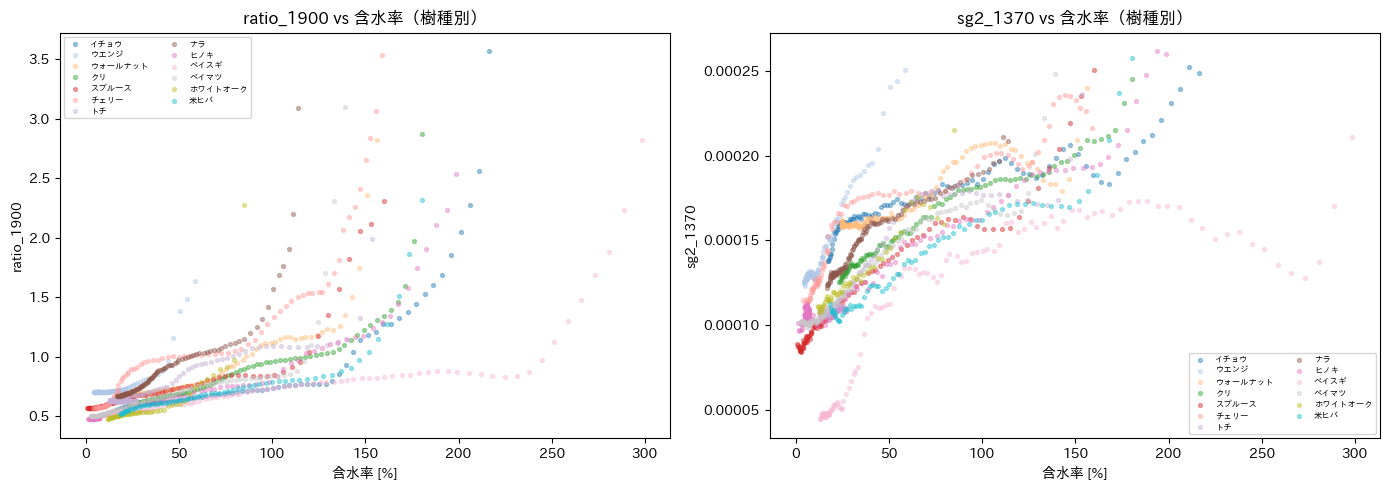

In [4]:
# ratio_1900 vs 含水率の散布図（樹種別に色分け）
species_list = np.unique(groups)
cmap = plt.cm.tab20

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, sp in enumerate(species_list):
    mask  = groups == sp
    color = cmap(i / len(species_list))
    axes[0].scatter(y_train[mask], F_train[mask, 0], alpha=0.4, s=8,
                    color=color, label=sp)
    axes[1].scatter(y_train[mask], F_train[mask, 1], alpha=0.4, s=8,
                    color=color, label=sp)

axes[0].set_xlabel('含水率 [%]')
axes[0].set_ylabel('ratio_1900')
axes[0].set_title('ratio_1900 vs 含水率（樹種別）')
axes[0].legend(fontsize=6, ncol=2)

axes[1].set_xlabel('含水率 [%]')
axes[1].set_ylabel('sg2_1370')
axes[1].set_title('sg2_1370 vs 含水率（樹種別）')
axes[1].legend(fontsize=6, ncol=2)

plt.tight_layout()
plt.show()

## 2. LOSO CV 比較

| モデル | 説明 |
|---|---|
| baseline | SNV + PLS3（現ベスト） |
| pls3_aug | SNV + ratio_1900 を連結 → PLS3 |
| rf_4feat | 4特徴量 + RandomForest |
| ridge_4feat | 4特徴量 + Ridge |

In [5]:
results = {sp: {} for sp in np.unique(groups)}

for sp in np.unique(groups):
    val_mask = groups == sp
    tr_mask  = ~val_mask

    X_tr_snv, X_val_snv = X_train_snv[tr_mask], X_train_snv[val_mask]
    y_tr, y_val = y_train[tr_mask], y_train[val_mask]

    # 特徴量（fold内で再計算）
    sg1_tr  = sg(X_tr_snv,  deriv=1)
    sg2_tr  = sg(X_tr_snv,  deriv=2)
    sg1_val = sg(X_val_snv, deriv=1)
    sg2_val = sg(X_val_snv, deriv=2)
    F_tr  = make_features(sg1_tr,  sg2_tr,  WAVELEN)
    F_val = make_features(sg1_val, sg2_val, WAVELEN)

    # baseline
    pls = PLSRegression(n_components=3)
    pls.fit(X_tr_snv, y_tr)
    results[sp]['baseline'] = rmse(y_val, pls.predict(X_val_snv).ravel())

    # pls3_aug: SNV + ratio_1900 を連結
    X_tr_aug  = np.hstack([X_tr_snv,  F_tr[:,  [0]]])
    X_val_aug = np.hstack([X_val_snv, F_val[:, [0]]])
    pls2 = PLSRegression(n_components=3)
    pls2.fit(X_tr_aug, y_tr)
    results[sp]['pls3_aug'] = rmse(y_val, pls2.predict(X_val_aug).ravel())

    # rf_4feat
    rf = RandomForestRegressor(n_estimators=200, random_state=42)
    rf.fit(F_tr, y_tr)
    results[sp]['rf_4feat'] = rmse(y_val, rf.predict(F_val))

    # ridge_4feat
    ridge = Ridge(alpha=1.0)
    ridge.fit(F_tr, y_tr)
    results[sp]['ridge_4feat'] = rmse(y_val, ridge.predict(F_val))


df_res = pd.DataFrame(results).T
print(df_res.round(2).sort_values('baseline').to_string())
print()
for col in df_res.columns:
    print(f'{col:<12} mean: {df_res[col].mean():.4f}  median: {df_res[col].median():.4f}')

         baseline  pls3_aug  rf_4feat  ridge_4feat
スプルース        5.05      5.07     40.55        23.64
ベイマツ         6.51      6.55     28.19        26.12
クリ          10.83     10.83     16.26        28.86
トチ          12.70     12.69      8.28        19.12
ウォールナット     14.19     14.15     17.33        17.92
米ヒバ         14.41     14.45     10.72        36.86
ヒノキ         15.07     15.04     24.26        24.24
ホワイトオーク     15.55     15.55     17.22        18.39
イチョウ        18.20     18.21     17.22        40.35
ナラ          23.21     23.22     10.75        29.03
ウエンジ        34.62     34.54     15.91        35.11
チェリー        35.90     35.89     22.62        42.63
ベイスギ        71.33     71.26     60.03        74.43

baseline     mean: 21.3526  median: 15.0709
pls3_aug     mean: 21.3423  median: 15.0381
rf_4feat     mean: 22.2583  median: 17.2250
ridge_4feat  mean: 32.0535  median: 28.8625


In [6]:
# LOSOで最良だったモデルで提出（実行前に上のセル結果を確認）
# デフォルト: pls3_aug（SNV + ratio_1900 + PLS3）

X_tr_aug   = np.hstack([X_train_snv, F_train[:, [0]]])
X_test_aug = np.hstack([X_test_snv,  F_test[:,  [0]]])

pls_final = PLSRegression(n_components=3)
pls_final.fit(X_tr_aug, y_train)
y_pred = np.clip(pls_final.predict(X_test_aug).ravel(), y_min, y_max)

fname = '../submissions/submission_pls3_ratio1900.csv'
pd.DataFrame({
    'sample number': test['sample number'],
    '含水率': y_pred
}).to_csv(fname, index=False, header=False)
print(f'保存完了: {fname}')

保存完了: ../submissions/submission_pls3_ratio1900.csv
